<a href="https://colab.research.google.com/github/arshads1206/credit-card-fraud-detection/blob/main/CreditcardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
import os

print("Dataset path:", path)
print("Files inside folder:", os.listdir(path))

Dataset path: /kaggle/input/creditcardfraud
Files inside folder: ['creditcard.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "creditcard.csv"))

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df['Class'].value_counts())

fraud_percentage = df['Class'].mean() * 100
print(f"\nFraud Percentage: {fraud_percentage:.4f}%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9727243053242681


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results:\n")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Random Forest Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.952908497036969


In [ ]:
def risk_score(prob):
    return round(prob * 100, 2)

sample_probs = rf_proba[:10]

for i, p in enumerate(sample_probs):
    print(f"Transaction {i+1} -> Fraud Probability: {p:.4f} | Risk Score: {risk_score(p)}")

Transaction 1 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 2 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 3 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 4 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 5 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 6 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 7 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 8 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 9 -> Fraud Probability: 0.0000 | Risk Score: 0.0
Transaction 10 -> Fraud Probability: 0.0000 | Risk Score: 0.0


In [ ]:
import numpy as np

# Get top 10 highest risk transactions
top_indices = np.argsort(rf_proba)[-10:]

for idx in top_indices:
    print(f"Fraud Probability: {rf_proba[idx]:.4f} | Risk Score: {risk_score(rf_proba[idx])} | Actual: {y_test.iloc[idx]}")

Fraud Probability: 0.9900 | Risk Score: 99.0 | Actual: 1
Fraud Probability: 0.9900 | Risk Score: 99.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1
Fraud Probability: 1.0000 | Risk Score: 100.0 | Actual: 1


In [ ]:
threshold = 0.3

custom_pred = (rf_proba > threshold).astype(int)

print("Custom Threshold Results (0.3):\n")
print(classification_report(y_test, custom_pred))

Custom Threshold Results (0.3):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



V14    0.179857
V10    0.115442
V12    0.096206
V4     0.095646
V17    0.095113
V3     0.068669
V11    0.056112
V16    0.040303
V2     0.036265
V9     0.026888
dtype: float64


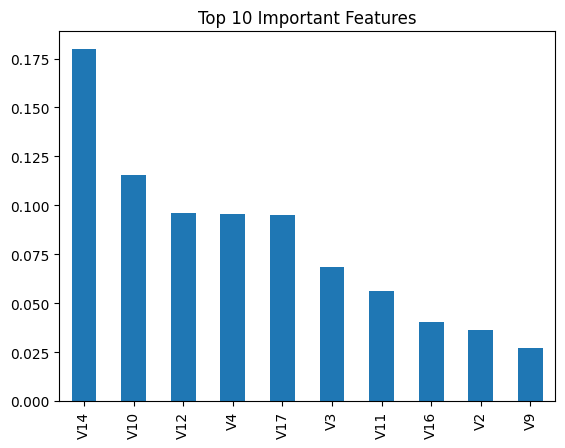

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importances.head(10))

# Plot top 10 features
feature_importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_sm).value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_sm, y_train_sm)

sm_pred = rf_smote.predict(X_test)
sm_proba = rf_smote.predict_proba(X_test)[:,1]

print("SMOTE Random Forest Results:\n")
print(classification_report(y_test, sm_pred))
print("ROC-AUC:", roc_auc_score(y_test, sm_proba))

SMOTE Random Forest Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9644234399584257


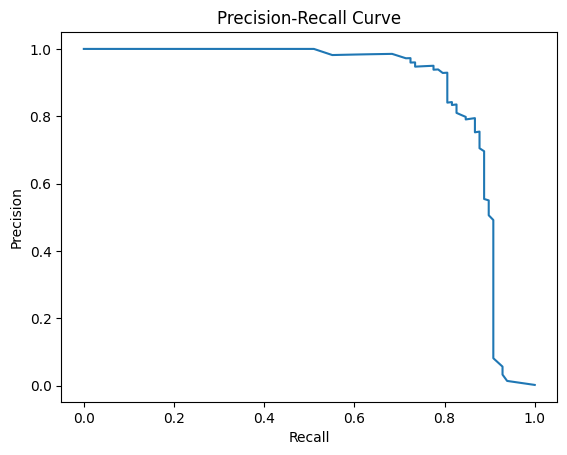

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Use SMOTE model probabilities if you ran SMOTE
probs = sm_proba  # if using SMOTE
# probs = rf_proba  # if not using SMOTE

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])
print("Precision at Best:", precision[best_index])
print("Recall at Best:", recall[best_index])

Best Threshold: 0.7
Best F1 Score: 0.8633879731673089
Precision at Best: 0.9294117647058824
Recall at Best: 0.8061224489795918


In [ ]:
optimal_pred = (probs > best_threshold).astype(int)

from sklearn.metrics import classification_report

print("Optimized Threshold Results:\n")
print(classification_report(y_test, optimal_pred))

Optimized Threshold Results:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
import joblib

joblib.dump(rf_smote, "fraud_model.pkl")
from google.colab import files
files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>